https://www.kaggle.com/competitions/playground-series-s6e1

##Setup and Data Download
This initial cell remains the same. It sets up the environment, downloads the dataset, and sets a random seed for reproducibility.

In [ ]:
import torch
import os
import random
import numpy as np

# Set a fixed random seed for reproducibility
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# === DIRECT KAGGLE CREDENTIALS ===
os.environ['KAGGLE_USERNAME'] = 'asd147'
os.environ['KAGGLE_KEY']     = '6a95e405001115800e2e18044513a965'
# ===================================


# Always download (kaggle will overwrite the zip if it exists)
!kaggle datasets download -d andrewmvd/car-plate-detection


# Force-overwrite when unzipping (-o = overwrite without prompt)
!unzip -q -o car-plate-detection.zip -d ./data


## Clean up
!rm -f car-plate-detection.zip

# Check for GPU availability and set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/car-plate-detection
License(s): CC0-1.0
100% 203M/203M [00:00<00:00, 255MB/s]

Using device: cuda


##Data Loading and Preprocessing with Augmentation
The PlateDataset class is updated to handle separate transformations for training and validation. The training set will now include data augmentation to improve model robustness.

In [ ]:
import xml.etree.ElementTree as ET
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms

class PlateDataset(Dataset):
    def __init__(self, data_dir, image_files, transform=None):
        self.img_dir = os.path.join(data_dir, 'images')
        self.ann_dir = os.path.join(data_dir, 'annotations')
        self.transform = transform
        # We pass the specific list of files for this dataset (train or val)
        self.image_files = image_files

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # Load image
        img_name = self.image_files[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        original_w, original_h = image.size

        # Load annotation
        ann_name = img_name.replace('.png', '.xml')
        ann_path = os.path.join(self.ann_dir, ann_name)
        tree = ET.parse(ann_path)
        root = tree.getroot()

        bndbox = root.find('object').find('bndbox')
        xmin = int(bndbox.find('xmin').text)
        ymin = int(bndbox.find('ymin').text)
        xmax = int(bndbox.find('xmax').text)
        ymax = int(bndbox.find('ymax').text)

        bbox = [xmin, ymin, xmax, ymax]

        if self.transform:
            image = self.transform(image)

        # Scale bounding box to match transformed image size
        # The coordinates are normalized to be between 0 and 1
        new_bbox = [
            bbox[0] / original_w,
            bbox[1] / original_h,
            bbox[2] / original_w,
            bbox[3] / original_h
        ]

        return image, torch.tensor(new_bbox, dtype=torch.float32)

# Define transformations for training (with augmentation) and validation (without)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

##Splitting Data and Creating DataLoaders
The data splitting logic is adjusted to create lists of filenames for the training and validation sets, which are then passed to the PlateDataset instances.

In [ ]:
from sklearn.model_selection import train_test_split

data_dir = './data'
all_image_files = sorted([f for f in os.listdir(os.path.join(data_dir, 'images')) if f.endswith('.png')])

# Split files into training and validation sets
train_files, val_files = train_test_split(all_image_files, test_size=0.2, random_state=42)

# Create dataset instances with respective transformations
train_dataset = PlateDataset(data_dir=data_dir, image_files=train_files, transform=train_transform)
val_dataset = PlateDataset(data_dir=data_dir, image_files=val_files, transform=val_transform)


print(f"Total number of images: {len(all_image_files)}")
print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

Total number of images: 433
Training set size: 346
Validation set size: 87


##Improved Model Architecture with Fine-Tuning
The model creation function is modified to unfreeze the last convolutional block (layer4) of the ResNet18 model, allowing it to be fine-tuned during training.

In [ ]:
import torch.nn as nn
from torchvision import models

def create_finetune_model():
    # Load a pre-trained ResNet18 model
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    # Freeze all parameters first
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze the parameters of the last convolutional block (layer4)
    for param in model.layer4.parameters():
        param.requires_grad = True

    # Get the number of input features for the classifier
    num_ftrs = model.fc.in_features

    # Replace the final fully connected layer and make it trainable
    model.fc = nn.Sequential(
        nn.Linear(num_ftrs, 4),
        nn.Sigmoid() # Use Sigmoid to ensure output is between 0 and 1
    )

    return model

model = create_finetune_model()
model = model.to(device)

# Print the number of trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {trainable_params}")
print("\nModel Architecture:")
print(model)

Number of trainable parameters: 8395780

Model Architecture:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, 

##Training the Model
The training loop is updated to use the SmoothL1Loss function and a StepLR learning rate scheduler.

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from tqdm import tqdm

# Define loss function, optimizer, and learning rate scheduler
criterion = nn.SmoothL1Loss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
scheduler = StepLR(optimizer, step_size=10, gamma=0.1) # Reduce LR every 10 epochs

# Training loop
num_epochs = 50 # Let's train for the same number of epochs to compare
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': []}

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    for images, bboxes in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        images, bboxes = images.to(device), bboxes.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, bboxes)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    train_loss /= len(train_loader.dataset)
    history['train_loss'].append(train_loss)

    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, bboxes in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            images, bboxes = images.to(device), bboxes.to(device)
            outputs = model(images)
            loss = criterion(outputs, bboxes)
            val_loss += loss.item() * images.size(0)

    val_loss /= len(val_loader.dataset)
    history['val_loss'].append(val_loss)

    # Step the scheduler
    scheduler.step()

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {scheduler.get_last_lr()[0]:.6f}")

    # Save the model with the best validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model_finetuned.pth')
        print(f"Model saved with new best validation loss: {best_val_loss:.4f}")

# Load the best model for evaluation
model.load_state_dict(torch.load('best_model_finetuned.pth'))
print("\nLoaded best fine-tuned model for evaluation.")

Epoch 1/50 [Val]: 100%|██████████| 3/3 [00:01<00:00,  2.37it/s]


Epoch 1/50, Train Loss: 0.0231, Val Loss: 0.0233, LR: 0.001000
Model saved with new best validation loss: 0.0233


Epoch 2/50 [Val]: 100%|██████████| 3/3 [00:01<00:00,  2.42it/s]


Epoch 2/50, Train Loss: 0.0124, Val Loss: 0.0135, LR: 0.001000
Model saved with new best validation loss: 0.0135


Epoch 3/50 [Val]: 100%|██████████| 3/3 [00:01<00:00,  2.38it/s]


...

Epoch 48/50, Train Loss: 0.0010, Val Loss: 0.0034, LR: 0.000000


Epoch 49/50 [Val]: 100%|██████████| 3/3 [00:01<00:00,  2.41it/s]


Epoch 49/50, Train Loss: 0.0010, Val Loss: 0.0034, LR: 0.000000


Epoch 50/50 [Val]: 100%|██████████| 3/3 [00:01<00:00,  2.40it/s]

Epoch 50/50, Train Loss: 0.0009, Val Loss: 0.0034, LR: 0.000000

Loaded best fine-tuned model for evaluation.


##Performance Evaluation with Intersection over Union (IoU)
The model's performance is evaluated using the Intersection over Union (IoU) metric. IoU is a standard metric for object detection that measures the overlap between the predicted and ground-truth bounding boxes. A function is defined to calculate the average IoU score across the entire validation set.

In [ ]:
def calculate_iou(box1, box2):
    # box format: [xmin, ymin, xmax, ymax]

    # Calculate intersection coordinates
    inter_xmin = torch.max(box1[:, 0], box2[:, 0])
    inter_ymin = torch.max(box1[:, 1], box2[:, 1])
    inter_xmax = torch.min(box1[:, 2], box2[:, 2])
    inter_ymax = torch.min(box1[:, 3], box2[:, 3])

    # Calculate intersection area
    inter_area = torch.clamp(inter_xmax - inter_xmin, min=0) * torch.clamp(inter_ymax - inter_ymin, min=0)

    # Calculate union area
    box1_area = (box1[:, 2] - box1[:, 0]) * (box1[:, 3] - box1[:, 1])
    box2_area = (box2[:, 2] - box2[:, 0]) * (box2[:, 3] - box2[:, 1])
    union_area = box1_area + box2_area - inter_area

    # Calculate IoU
    iou = inter_area / (union_area + 1e-6) # Add epsilon to avoid division by zero
    return iou

# Evaluate the model on the validation set
model.eval()
total_iou = 0.0
with torch.no_grad():
    for images, true_boxes in val_loader:
        images, true_boxes = images.to(device), true_boxes.to(device)

        # Get model predictions
        pred_boxes = model(images)

        # Calculate IoU for the batch
        iou_scores = calculate_iou(pred_boxes, true_boxes)
        total_iou += iou_scores.sum().item()

avg_iou = total_iou / len(val_dataset)
print(f"Average Intersection over Union (IoU) on the validation set: {avg_iou:.4f}")

Average Intersection over Union (IoU) on the validation set: 0.3999


##Visualizing Predictions
The model's predictions are visualized on a sample of images from the validation set. This allows for a qualitative assessment of the model's performance by comparing the predicted bounding boxes (red) with the ground-truth bounding boxes (green) on the actual images.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torchvision
import random

def visualize_predictions(dataset, model, indices=None, num_samples=5):
    if indices is None:
        # Randomly select num_samples indices
        indices = random.sample(range(len(dataset)), num_samples)
    else:
        num_samples = len(indices)

    fig, axes = plt.subplots(1, num_samples, figsize=(20, 5))

    model.eval()
    with torch.no_grad():
        for i, idx in enumerate(indices):
            image_tensor, true_box = dataset[idx]

            # Un-normalize the image for visualization
            inv_normalize = transforms.Normalize(
                mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
                std=[1/0.229, 1/0.224, 1/0.225]
            )
            img_vis = inv_normalize(image_tensor)
            img_vis = torchvision.transforms.ToPILImage()(img_vis)

            # Get prediction
            pred_box = model(image_tensor.unsqueeze(0).to(device)).squeeze(0).cpu()

            # Plot image
            ax = axes[i]
            ax.imshow(img_vis)
            ax.axis('off')

            # Image dimensions
            W, H = img_vis.size

            # Draw ground-truth box (Green)
            xmin, ymin, xmax, ymax = true_box
            gt_rect = patches.Rectangle((xmin*W, ymin*H), (xmax-xmin)*W, (ymax-ymin)*H, linewidth=2, edgecolor='g', facecolor='none', label='Ground Truth')
            ax.add_patch(gt_rect)

            # Draw predicted box (Red)
            xmin, ymin, xmax, ymax = pred_box
            pred_rect = patches.Rectangle((xmin*W, ymin*H), (xmax-xmin)*W, (ymax-ymin)*H, linewidth=2, edgecolor='r', facecolor='none', label='Prediction')
            ax.add_patch(pred_rect)

    plt.legend(handles=[gt_rect, pred_rect], bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

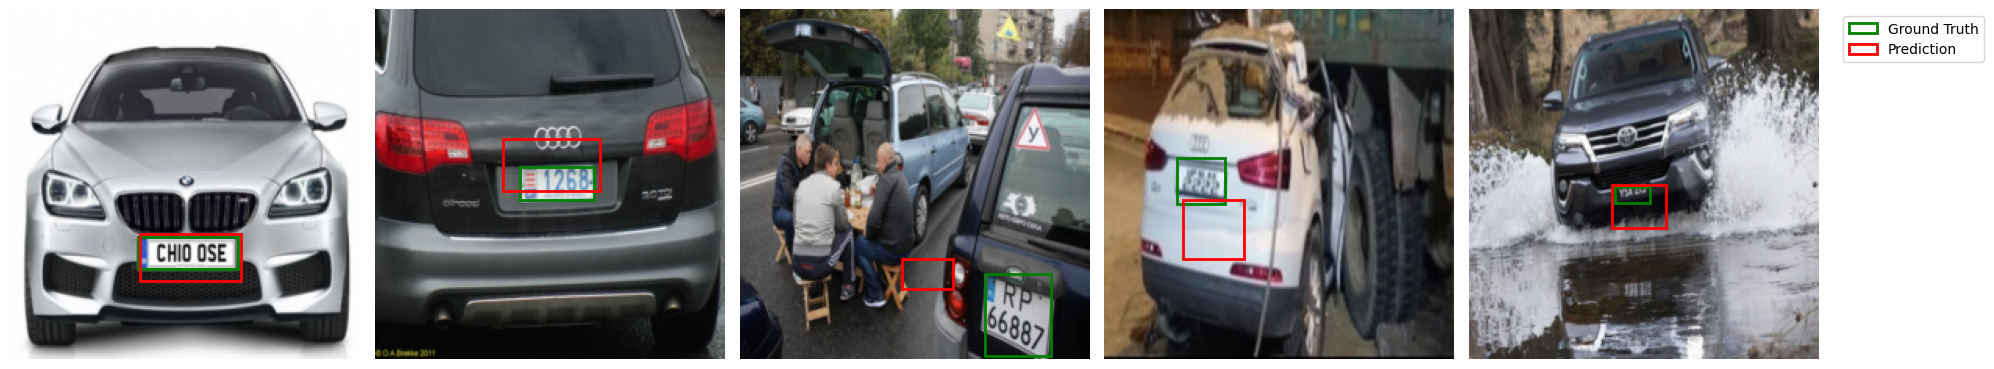

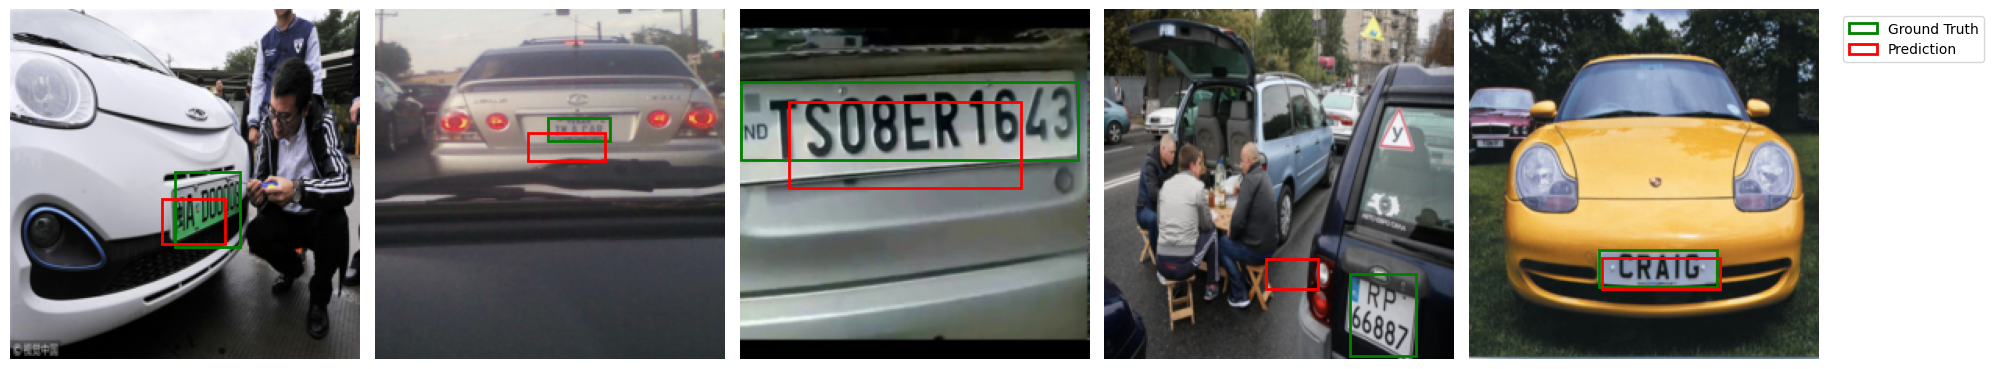

In [ ]:
visualize_predictions(val_dataset, model)
visualize_predictions(val_dataset, model, indices=[0, 1, 2, 3, 4])